## **Setup**

In [1]:
# Notebook autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Path setup
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [3]:
# Libraries
import os as os
import json as json
import pandas as pd
import matplotlib.pyplot as plt
from importlib.resources import files

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize
from chatGnT.models import predict
from chatGnT.models.transformer import TransformerModel_MultiTask, TransformerModel_SingleTask
# Setup
ensure_dirs(CFG)
ASSETS = files("chatGnT.assets")

## **Load Models**

In [4]:
# Load models
model_mt, vocab_mt_amt, vocab_mt_ingred, config_mt = predict.load_model_mt(
    ASSETS / "model_mt.pt", TransformerModel_MultiTask)
with open(ASSETS / "metrics_mt.json", "r") as f:
    metrics_mt = json.load(f)
train_losses_mt = metrics_mt["train_loss"]
val_losses_mt = metrics_mt["val_loss"]

model_st, vocab_st, config_st = predict.load_model_st(
    ASSETS / "model_st.pt", TransformerModel_SingleTask)
with open(ASSETS / "metrics_st.json", "r") as f:
    metrics_st = json.load(f)
train_losses_st = metrics_st["train_loss"]
val_losses_st = metrics_st["val_loss"]


/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)
/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


## **Plot Loss Curves**

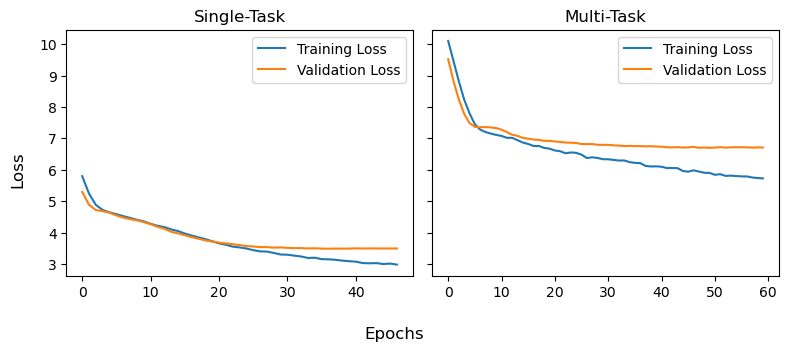

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

# --- Single-task ---
axes[0].plot(train_losses_st, label='Training Loss')
axes[0].plot(val_losses_st, label='Validation Loss')
axes[0].set_title('Single-Task')
axes[0].legend()

# --- Multi-task ---
axes[1].plot(train_losses_mt, label='Training Loss')
axes[1].plot(val_losses_mt, label='Validation Loss')
axes[1].set_title('Multi-Task')
axes[1].legend()

# Shared labels
fig.supxlabel('Epochs')
fig.supylabel('Loss')

plt.tight_layout()
plt.show()

# Save this figure
fig.savefig(CFG.outputs_dir / "figures/training_loss.png")

## **Run with Test User Input**

#### **Single Task Model**

In [6]:
result = predict.generate_st_from_input(
    model_st,
    vocab_st,
    "gin"
)

print(result["lines"])


/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['1 part gin', '0.75 part vodka', '1 part raspberry syrup']


In [7]:
result = predict.generate_st_from_input(
    model_st,
    vocab_st,
    "Cosmopolitan",
    recipe_prefix_len=2
)

print(result["start_tokens"])
print(result["lines"])

['<amt>1.25 parts</amt>', '<ingred>vodka</ingred>', '<amt>0.25 part</amt>', '<ingred>lime-juice</ingred>']
['1.25 parts vodka', '0.25 part lime juice', '1 orange']


#### **Multi Task Model**

In [8]:
result = predict.generate_mt_from_input(
    model_mt,
    vocab_mt_amt,
    vocab_mt_ingred,
    "gin"
)

print(result["lines"])


['1 part gin', '1 part sweet vermouth', '0.5 part bitters']


In [9]:
result = predict.generate_mt_from_input(
    model_mt,
    vocab_mt_amt,
    vocab_mt_ingred,
    "Cosmopolitan",
    recipe_prefix_len=2
)

print(result["start_tokens"])
print(result["lines"])

[('<amt>1.25 parts</amt>', '<ingred>vodka</ingred>'), ('<amt>0.25 part</amt>', '<ingred>lime-juice</ingred>')]
['1.25 parts vodka', '0.25 part lime juice', '0.333 part sugar', '1 lemon']


## **Generate Recipes & Check Length**

In [10]:
# Sample 5 ingredients from the top 20 most common ingredients in the training data and 
# 5 ingredients from the least 20 common ingredients that appear at least 2 times in
# the training data.

df = load.load_all()
df_clean = preprocess.clean_recipes(df)
df_clean_filt = preprocess.filter_recipes(df_clean)

# Get 20 most common ingredients in df_clean_filt
counts = df_clean_filt['ingred'].value_counts()
top_20 = counts.head(20)
bottom_20 = counts[counts > 1].tail(20)

top_5_sample = top_20.sample(5, random_state=42)
bottom_5_sample = bottom_20.sample(5, random_state=42)

top_prompts = top_5_sample.index.tolist()
bottom_prompts = bottom_5_sample.index.tolist()

# Sample 10 recipes at random
recipe_sample = df_clean_filt.sample(10, random_state=42)
recipe_prompts = recipe_sample["name"].tolist()

In [ ]:
# rows = []
# def add_result(model, prompt, prompt_type, output):
#     rows.append({
#         "model": model,
#         "prompt": prompt,
#         "prompt-type": prompt_type,
#         "recipe-length": len(output["lines"]),
#         "recipe": output["lines"]

#     })

# # ingredient-conditioned prompts
# for prompt in top_prompts:
#     for _ in range(10):
#         st_out = predict.generate_st_from_input(model_st, vocab_st, prompt)
#         mt_out = predict.generate_mt_from_input(model_mt, vocab_mt_amt, vocab_mt_ingred, prompt)

#         add_result("st", prompt, "ingred-top", st_out)
#         add_result("mt", prompt, "ingred-top", mt_out)

# for prompt in bottom_prompts:
#     for _ in range(10):
#         st_out = predict.generate_st_from_input(model_st, vocab_st, prompt)
#         mt_out = predict.generate_mt_from_input(model_mt, vocab_mt_amt, vocab_mt_ingred, prompt)

#         add_result("st", prompt, "ingred-bottom", st_out)
#         add_result("mt", prompt, "ingred-bottom", mt_out)

# # full recipe prompts
# for prompt in recipe_prompts:
#     for _ in range(10):
#         st_out = predict.generate_st_from_input(model_st, vocab_st, prompt, recipe_prefix_len=2)
#         mt_out = predict.generate_mt_from_input(model_mt, vocab_mt_amt, vocab_mt_ingred, prompt, recipe_prefix_len=2)

#         add_result("st", prompt, "recipe", st_out)
#         add_result("mt", prompt, "recipe", mt_out)

# results = pd.DataFrame(rows)
# results.to_csv(CFG.outputs_dir / "tables/check_gen_recipes.csv", index=False)

In [12]:
# Sumamrize length check results to table
results = pd.read_csv(CFG.outputs_dir / "tables/check_gen_recipes.csv")

# Add summary of input recipes to table
df_clean_filt["recipe-length"] = df_clean_filt.groupby("id")["ingred"].transform("count")
df_clean_filt_summ = df_clean_filt[["id", "recipe-length"]].drop_duplicates()
df_clean_filt_summ["prompt-type"] = None

# Summarize
gen_summary = (
    results.groupby(["model", "prompt-type"])["recipe-length"]
    .describe()
    .reset_index()
)

input_summary = (
    df_clean_filt_summ.groupby(["prompt-type"], dropna=False)["recipe-length"]
    .describe()
    .reset_index()
)

combined = pd.concat([gen_summary, input_summary], ignore_index=True, sort=False)

combined.to_csv(CFG.outputs_dir / "tables/check_gen_recipes_length_summary.csv", index=False)



In [13]:
# Check what percentage of recipes are between 2-10 token pairs long
mask = (results["recipe-length"] >= 2) & (results["recipe-length"] <= 10)

summary = (
    results
    .assign(in_range=mask)
    .groupby(["model", "prompt-type"])["in_range"]
    .mean()
    .mul(100)
    .reset_index(name="pct_2_to_10")
)

print(summary)


  model    prompt-type  pct_2_to_10
0    mt         ingred         88.0
1    mt     ingred-top         96.0
2    mt         recipe        100.0
3    st  ingred-bottom        100.0
4    st     ingred-top        100.0
5    st         recipe        100.0


## **Check Recipes not in Training Data**

In [14]:
# Check how many generated recipes exactly match recipes in the original filtered database
import ast

if "results" not in globals():
    results = pd.read_csv(CFG.outputs_dir / "tables/check_gen_recipes.csv")

# Convert original database recipes to the same human-readable line format used by predictions.
df_clean_filt_for_match = df_clean_filt.copy()
df_clean_filt_for_match["recipe_line"] = (
    df_clean_filt_for_match["amt_unit"].fillna("").astype(str).str.strip()
    + " "
    + df_clean_filt_for_match["ingred"].fillna("").astype(str).str.replace("-", " ", regex=False).str.strip()
)
df_clean_filt_for_match["recipe_line"] = (
    df_clean_filt_for_match["recipe_line"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.casefold()
)

original_recipe_lookup = (
    df_clean_filt_for_match.groupby(["id", "name"], sort=False)["recipe_line"]
    .agg(tuple)
    .reset_index(name="recipe_key")
)
original_recipe_keys = set(original_recipe_lookup["recipe_key"])

original_match_lookup = (
    original_recipe_lookup.groupby("recipe_key", sort=False)
    .agg(
        original_ids=("id", list),
        original_names=("name", lambda names: sorted(set(names))),
    )
    .reset_index()
)

def make_generated_recipe_key(recipe):
    lines = recipe if isinstance(recipe, list) else ast.literal_eval(recipe)
    return tuple(
        pd.Series(lines, dtype="string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.casefold()
        .tolist()
    )

generated_recipe_check = results.copy()
generated_recipe_check["recipe_key"] = generated_recipe_check["recipe"].apply(make_generated_recipe_key)
generated_recipe_check["in-original-db"] = generated_recipe_check["recipe_key"].isin(original_recipe_keys)
generated_recipe_check = generated_recipe_check.merge(
    original_match_lookup,
    on="recipe_key",
    how="left",
)

match_summary = (
    generated_recipe_check.groupby(["model", "prompt-type"], dropna=False)["in-original-db"]
    .agg(generated_recipes="size", recipes_in_original_db="sum")
    .reset_index()
)
match_summary["pct_in_original_db"] = (
    match_summary["recipes_in_original_db"] / match_summary["generated_recipes"] * 100
).round(2)

overall_match_summary = pd.DataFrame({
    "generated_recipes": [len(generated_recipe_check)],
    "recipes_in_original_db": [generated_recipe_check["in-original-db"].sum()],
})
overall_match_summary["pct_in_original_db"] = (
    overall_match_summary["recipes_in_original_db"]
    / overall_match_summary["generated_recipes"]
    * 100
).round(2)

generated_recipe_check.to_csv(
    CFG.outputs_dir / "tables/check_gen_recipes_original_db_matches.csv",
    index=False,
)
match_summary.to_csv(
    CFG.outputs_dir / "tables/check_gen_recipes_original_db_match_summary.csv",
    index=False,
)

display(overall_match_summary)
display(match_summary)


,generated_recipes,recipes_in_original_db,pct_in_original_db
0,400,20,5.0


,model,prompt-type,generated_recipes,recipes_in_original_db,pct_in_original_db
0,mt,ingred,50,0,0.0
1,mt,ingred-top,50,1,2.0
2,mt,recipe,100,10,10.0
3,st,ingred-bottom,50,0,0.0
4,st,ingred-top,50,0,0.0
5,st,recipe,100,9,9.0
